Dataset Preview:
   Gender  Tenure  MonthlyCharges    ContractType InternetService  Churn
0    Male      47       50.191670  Month-to-month             DSL      0
1  Female      12       96.108831        One year     Fiber optic      0
2    Male      62       55.426776        Two year              No      0
3    Male       8      114.907120  Month-to-month             DSL      1
4    Male      21      116.231020  Month-to-month             DSL      1

Model Evaluation:
Accuracy: 0.9175

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       314
           1       0.84      0.77      0.80        86

    accuracy                           0.92       400
   macro avg       0.89      0.86      0.87       400
weighted avg       0.92      0.92      0.92       400



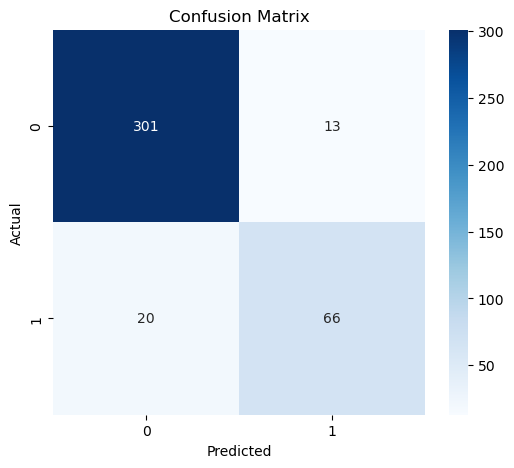

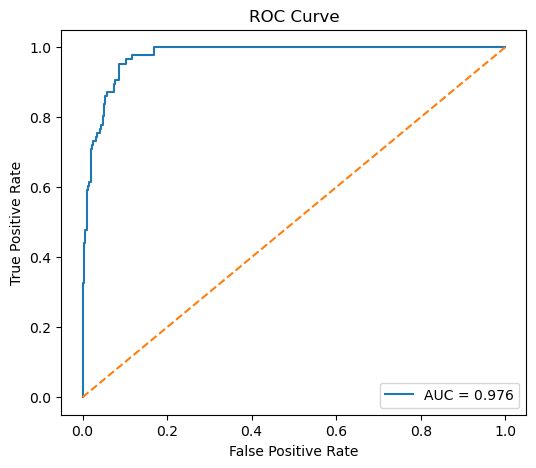

AUC Score: 0.976

Training Accuracy: 0.9094
Testing Accuracy: 0.9175


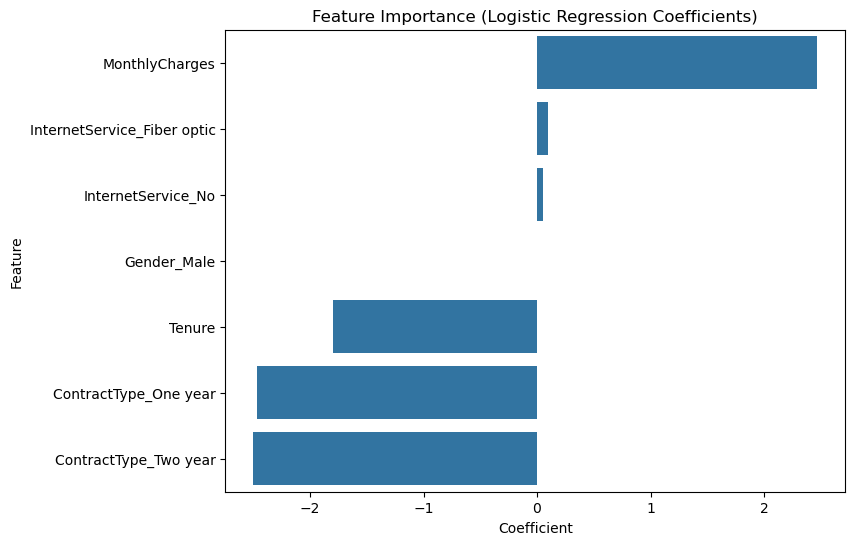


Top Influential Features:
                       Feature  Coefficient
1               MonthlyCharges     2.467827
5  InternetService_Fiber optic     0.095938
6           InternetService_No     0.054561
2                  Gender_Male     0.000333
0                       Tenure    -1.800581


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)

n = 2000

data = pd.DataFrame({
    "Gender": np.random.choice(["Male", "Female"], n),
    "Tenure": np.random.randint(1, 72, n),
    "MonthlyCharges": np.random.uniform(20, 120, n),
    "ContractType": np.random.choice(["Month-to-month", "One year", "Two year"], n),
    "InternetService": np.random.choice(["DSL", "Fiber optic", "No"], n)
})

data["Churn"] = (
    (data["ContractType"] == "Month-to-month").astype(int) * 0.4 +
    (data["MonthlyCharges"] > 80).astype(int) * 0.3 +
    (data["Tenure"] < 12).astype(int) * 0.3 +
    np.random.rand(n) * 0.2
)

data["Churn"] = (data["Churn"] > 0.6).astype(int)

print("Dataset Preview:")
print(data.head())

data_encoded = pd.get_dummies(data, drop_first=True)

X = data_encoded.drop("Churn", axis=1)
y = data_encoded["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("\nModel Evaluation:")
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", round(accuracy, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="AUC = " + str(round(auc_score, 4)))
plt.plot([0,1], [0,1], linestyle="--")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

print("AUC Score:", round(auc_score, 4))

train_accuracy = accuracy_score(y_train, model.predict(X_train))
test_accuracy = accuracy_score(y_test, y_pred)

print("\nTraining Accuracy:", round(train_accuracy, 4))
print("Testing Accuracy:", round(test_accuracy, 4))

feature_names = data_encoded.drop("Churn", axis=1).columns
coefficients = model.coef_[0]

importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

importance = importance.sort_values(by="Coefficient", ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(x="Coefficient", y="Feature", data=importance)
plt.title("Feature Importance (Logistic Regression Coefficients)")
plt.show()

print("\nTop Influential Features:")
print(importance.head())